# MoodTrack: Synthetic Mental Health Dataset

## Section 1 - Introduction 

In this section, we generate a synthetic PHQ-9-like dataset to simulate longitudinal mood patterns. Real patient data cannot be used due to privacy constraints, so we create realistic trajectories such as improvement, relapse, and fluctuation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Section 2 - Data generation


In [2]:

import numpy as np
import pandas as pd

np.random.seed(42)

# -----------------------------
# PARAMETERS
# -----------------------------
n_users = 300
n_weeks = 12

trajectory_types = [
    "stable_low",
    "stable_moderate",
    "improving",
    "worsening",
    "relapse",
    "fluctuating"
]

trajectory_probs = [0.20, 0.20, 0.20, 0.15, 0.10, 0.15]

# -----------------------------
# HELPER FUNCTION
# -----------------------------
def phq9_category(score):
    if score <= 4:
        return "minimal"
    elif score <= 9:
        return "mild"
    elif score <= 14:
        return "moderate"
    elif score <= 19:
        return "moderately_severe"
    else:
        return "severe"

# -----------------------------
# DATA GENERATION
# -----------------------------
records = []

for user_id in range(1, n_users + 1):
    age = int(np.clip(np.random.normal(38, 12), 18, 75))
    sex = np.random.choice(["female", "male"], p=[0.58, 0.42])
    trajectory = np.random.choice(trajectory_types, p=trajectory_probs)

    baseline = {
        "stable_low": np.random.normal(4, 2),
        "stable_moderate": np.random.normal(12, 3),
        "improving": np.random.normal(17, 4),
        "worsening": np.random.normal(6, 3),
        "relapse": np.random.normal(9, 3),
        "fluctuating": np.random.normal(11, 4),
    }[trajectory]

    for week in range(1, n_weeks + 1):
        noise = np.random.normal(0, 1.8)

        if trajectory == "stable_low":
            score = baseline + noise

        elif trajectory == "stable_moderate":
            score = baseline + noise

        elif trajectory == "improving":
            score = baseline - (week - 1) * np.random.uniform(0.7, 1.2) + noise

        elif trajectory == "worsening":
            score = baseline + (week - 1) * np.random.uniform(0.6, 1.1) + noise

        elif trajectory == "relapse":
            if week <= 6:
                score = baseline - week * np.random.uniform(0.4, 0.9) + noise
            else:
                score = baseline - 4 + (week - 6) * np.random.uniform(1.0, 1.7) + noise

        elif trajectory == "fluctuating":
            score = baseline + 4 * np.sin(week / 1.5) + noise

        # keep PHQ-9 range valid
        score = int(np.clip(round(score), 0, 27))

        records.append({
            "user_id": f"U{user_id:04d}",
            "week": week,
            "age": age,
            "sex": sex,
            "trajectory_type": trajectory,
            "phq9_score": score,
            "phq9_category": phq9_category(score),
            "sleep_hours": round(np.clip(np.random.normal(7 - score * 0.08, 1.0), 3, 10), 1),
            "physical_activity_days": int(np.clip(round(np.random.normal(4 - score * 0.12, 1.5)), 0, 7)),
            "stress_level": int(np.clip(round(np.random.normal(3 + score * 0.22, 1.3)), 1, 10)),
            "medication_status": np.random.choice(
                ["none", "started", "ongoing"],
                p=[0.55, 0.15, 0.30]
            )
        })

# -----------------------------
# CREATE DATAFRAME
# -----------------------------
df = pd.DataFrame(records)

# Additional useful fields
df["high_risk_flag"] = df["phq9_score"] >= 15
df["created_at"] = pd.Timestamp("2026-01-01") + pd.to_timedelta((df["week"] - 1) * 7, unit="D")

# -----------------------------
# SAVE DATA
# -----------------------------
df.to_csv("moodtrack_dataset.csv", index=False)

print("Dataset generated successfully!")
print(df.head())


Dataset generated successfully!
  user_id  week  age   sex trajectory_type  phq9_score      phq9_category  \
0   U0001     1   43  male       improving          17  moderately_severe   
1   U0001     2   43  male       improving          17  moderately_severe   
2   U0001     3   43  male       improving          11           moderate   
3   U0001     4   43  male       improving          13           moderate   
4   U0001     5   43  male       improving          12           moderate   

   sleep_hours  physical_activity_days  stress_level medication_status  \
0          5.1                       1             3              none   
1          5.2                       1             6           ongoing   
2          8.7                       3             6              none   
3          5.4                       4             6              none   
4          5.5                       3             5           started   

   high_risk_flag created_at  
0            True 2026-01-01 

In this section, we explore the synthetic dataset generated to simulate longitudinal mental health patterns.

Each user is tracked over multiple weeks using a PHQ-9-like score ranging from 0 to 27. The dataset includes different trajectory types such as improving, worsening, relapse, and stable patterns.

This allows us to model realistic mental health trends without using sensitive or confidential data.

# Look at the data 

In [3]:

df.describe()

df.shape
df.columns

df.head()

,user_id,week,age,sex,trajectory_type,phq9_score,phq9_category,sleep_hours,physical_activity_days,stress_level,medication_status,high_risk_flag,created_at
0,U0001,1,43,male,improving,17,moderately_severe,5.1,1,3,none,True,2026-01-01
1,U0001,2,43,male,improving,17,moderately_severe,5.2,1,6,ongoing,True,2026-01-08
2,U0001,3,43,male,improving,11,moderate,8.7,3,6,none,False,2026-01-15
3,U0001,4,43,male,improving,13,moderate,5.4,4,6,none,False,2026-01-22
4,U0001,5,43,male,improving,12,moderate,5.5,3,5,started,False,2026-01-29


The dataset contains multiple observations per user, representing weekly measurements. Additional features such as sleep, stress, and activity levels are included to simulate real-world correlations.

# Distribution of PHQ9 scores

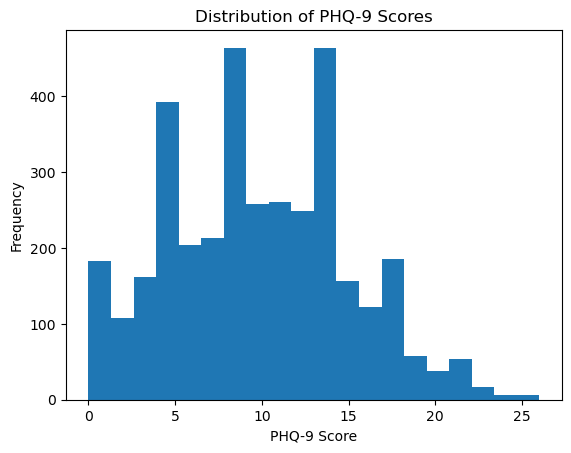

In [4]:
import matplotlib.pyplot as plt

plt.hist(df['phq9_score'], bins=20)
plt.xlabel("PHQ-9 Score")
plt.ylabel("Frequency")
plt.title("Distribution of PHQ-9 Scores")
plt.show()

The distribution shows a range of mental health states from minimal to severe. This diversity is important for building robust analytical models.

# Visualize trajectory 

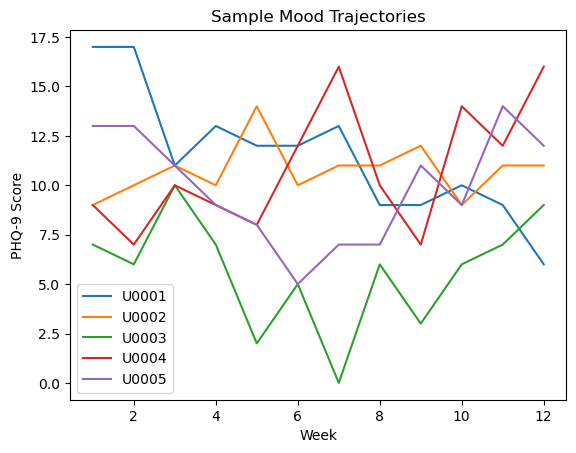

In [5]:
import matplotlib.pyplot as plt

sample_users = df['user_id'].unique()[:5]

for user in sample_users:
    temp = df[df['user_id'] == user]
    plt.plot(temp['week'], temp['phq9_score'], label=user)

plt.xlabel("Week")
plt.ylabel("PHQ-9 Score")
plt.title("Sample Mood Trajectories")
plt.legend()
plt.show()

The trajectories show different behavioral patterns:

- Some users show gradual improvement over time
- Others exhibit worsening symptoms
- Some display relapse patterns, where symptoms improve and then worsen again
- Fluctuating patterns reflect instability in mood

These patterns are intentionally simulated to reflect real-world longitudinal mental health dynamics.

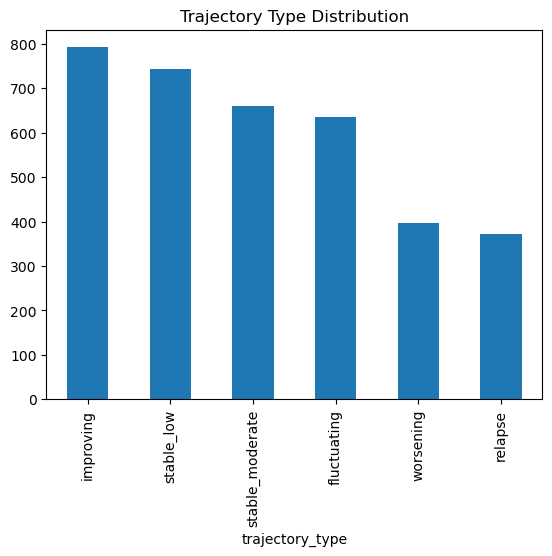

In [6]:
df['trajectory_type'].value_counts().plot(kind='bar')
plt.title("Trajectory Type Distribution")
plt.show()

The dataset includes a balanced mix of trajectory types to ensure that downstream models can generalize across different mental health patterns.

In [7]:
df['high_risk_flag'].value_counts()

high_risk_flag
False    2958
True      642
Name: count, dtype: int64

In [8]:
summary = (
    df.groupby("user_id")
    .agg(
        age=("age", "first"),
        sex=("sex", "first"),
        trajectory_type=("trajectory_type", "first"),
        baseline_score=("phq9_score", "first"),
        final_score=("phq9_score", "last"),
        mean_score=("phq9_score", "mean"),
        max_score=("phq9_score", "max"),
        min_score=("phq9_score", "min"),
        high_risk_weeks=("high_risk_flag", "sum")
    )
    .reset_index()
)

summary.to_csv("moodtrack_user_summary.csv", index=False)

High-risk observations correspond to PHQ-9 scores ≥ 15, which typically indicate moderate to severe depression levels.

This flag can later be used for classification tasks or alert systems in the application.

## Designing the MoodTrack Backend API

After generating and exploring the synthetic PHQ-9 dataset, the next step is to expose the data through a backend API.

The backend acts as the bridge between the dataset and the frontend dashboard. Instead of reading the CSV file directly in the browser, the frontend will request data from API endpoints.

This design follows a common production pattern where the frontend, backend, and database are separated into different layers.


Then:


### Installing Backend Dependencies

### 1. Go to backend folder

cd moodtrack/backend


Inside the `backend` folder, we initialize a Node.js project and install the required packages.

```bash
npm init -y
npm install express cors csv-parser
npm install --save-dev nodemon





### 2. Install packages

Run:

npm init -y

npm install express cors csv-parser

npm install --save-dev nodemon

nodemon is used during development because it automatically restarts the server whenever we save changes.


Then:

### API Endpoints

The backend exposes the following API endpoints:

| Endpoint | Purpose |
|---|---|
| `/api/health` | Checks whether the API is running |
| `/api/mood` | Returns all weekly mood records |
| `/api/users` | Returns unique user IDs |
| `/api/mood/:user_id` | Returns mood trajectory for one user |
| `/api/summary` | Returns user-level summary data |

### Backend Implementation (server.js)

Below is the complete implementation of the backend API using Node.js and Express.


```javascript
const express = require("express");
const cors = require("cors");
const fs = require("fs");
const csv = require("csv-parser");
const path = require("path");

const app = express();
const PORT = 5000;

app.use(cors());
app.use(express.json());

let moodData = [];
let summaryData = [];

// Function to load CSV files
function loadCSV(filePath) {
  return new Promise((resolve, reject) => {
    const results = [];

    fs.createReadStream(filePath)
      .pipe(csv())
      .on("data", (row) => results.push(row))
      .on("end", () => resolve(results))
      .on("error", (err) => reject(err));
  });
}

// Load data and start server
async function loadData() {
  try {
    moodData = await loadCSV(
      path.join(__dirname, "data", "moodtrack_synthetic_phq9_dataset.csv")
    );

    summaryData = await loadCSV(
      path.join(__dirname, "data", "moodtrack_user_summary.csv")
    );

    console.log("Mood data loaded:", moodData.length);
    console.log("Summary data loaded:", summaryData.length);

    // Start server
    app.listen(PORT, () => {
      console.log("MoodTrack API running on http://localhost:" + PORT);
    });

  } catch (error) {
    console.error("Error loading data:", error);
  }
}

// API routes
app.get("/api/health", (req, res) => {
  res.json({ status: "OK", message: "API is running" });
});

app.get("/api/mood", (req, res) => {
  res.json(moodData);
});

app.get("/api/users", (req, res) => {
  const users = [...new Set(moodData.map((row) => row.user_id))];
  res.json(users);
});

app.get("/api/mood/:user_id", (req, res) => {
  const userId = req.params.user_id;

  const userRecords = moodData.filter(
    (row) => row.user_id === userId
  );

  if (userRecords.length === 0) {
    return res.status(404).json({ error: "User not found" });
  }

  res.json(userRecords);
});

app.get("/api/summary", (req, res) => {
  res.json(summaryData);
});

// Initialize
loadData();
```

⚠️ Note: This code should NOT be run inside the Jupyter notebook.  
It should be saved as `server.js` inside the backend folder and executed using Node.js.

### Running the Backend

After writing `server.js`, we start the backend using:

```bash
npm run dev
```

The expected output is:

```bash 

Mood data loaded: 3600
Summary data loaded: 300
MoodTrack API running on http://localhost:5000

```



Finally:


### What We Learned

In this step, we converted a static CSV dataset into a simple backend API.

This is an important transition from data analysis to application development. Instead of keeping the data only inside a notebook, we created a service that can provide data to a web application.

This pattern is common in production systems:

```text
Dataset → Backend API → Frontend Dashboard
```

## Step 3: Building the Frontend Dashboard with React


After building the backend API, the next step is to create a frontend application that can visualize the data.

We use React to build an interactive dashboard that communicates with the backend API.

The frontend will:
- Fetch user data from the backend
- Allow selection of a user
- Display mood trajectories over time

This separation between backend and frontend reflects modern web application architecture.

### Creating the React Application

We create the frontend using Create React App:

```bash
npx create-react-app frontend
cd frontend
```

This sets up a complete React project with all required dependencies.

---

## 📦 Installing Required Libraries


### Installing Dependencies

We install additional libraries:

```bash
npm install axios recharts
```

axios is used to fetch data from the backend API

recharts is used to visualize time-series data


## ▶️ Running the Frontend

### Running the Frontend

Start the React development server:

```bash
npm start

```

The application will be available at: http://localhost:3000





### Common Issue: HOST Environment Variable

On some systems, you may encounter an error related to the `HOST` environment variable.

This can be resolved by running:

```bash
unset HOST
npm start
```

OR 


```bash

HOST=localhost npm start

```



### What We Achieved

At this stage, we have:

- A running backend API (Node.js + Express)
- A React frontend application
- A foundation for building an interactive dashboard

In the next step, we will connect the frontend to the backend and visualize the mood trajectories.

## Step 4: Connecting the Frontend to the Backend API

After confirming that the React application runs successfully, we replace the default React page with a custom MoodTrack dashboard.

The goal of this step is to connect the frontend to the backend API and visualize user-level mood trajectories.

The frontend performs two API requests:

1. It fetches the list of available users from the backend.
2. It fetches the weekly PHQ-9 trajectory for the selected user.

The selected user's PHQ-9 scores are then displayed as a line chart using the `recharts` library.

### API Endpoints Used by the Frontend

| Endpoint | Purpose |
|---|---|
| `http://localhost:5000/api/users` | Returns the list of synthetic user IDs |
| `http://localhost:5000/api/mood/:user_id` | Returns weekly PHQ-9 records for the selected user |



### Frontend Logic

The React frontend uses `useEffect` to fetch data from the backend.

The first `useEffect` loads the available user IDs when the page opens.

The second `useEffect` runs whenever a user is selected from the dropdown. It fetches the selected user's weekly mood records and updates the chart.


### Visualization

The PHQ-9 score is plotted over 12 weeks.

- The x-axis represents the week number.
- The y-axis represents the PHQ-9 score.
- Each line shows the mood trajectory of one selected synthetic user.

This helps us visually inspect whether a user is improving, worsening, stable, or fluctuating over time.


### What We Learned

In this step, we connected a React frontend to a Node.js backend API.

This is an important full-stack pattern:

```text
React frontend → API request → Express backend → CSV data → JSON response → Chart

### Current Status

At this stage, we have built a complete end-to-end system:

- Synthetic mental health dataset
- Backend API to serve the data
- React frontend to visualize user trajectories

This represents a minimal viable version of the MoodTrack system.

In the next steps, we extend the system with summary insights, advanced visualizations, and predictive modeling.

### Adding a Database Layer

Currently, MoodTrack uses CSV files as a data source.

To make the system production-ready, we introduce a database layer to store:

- user information
- weekly PHQ-9 scores
- summary metrics

### Data Science Extension

The MoodTrack system can be extended with predictive modeling to:

- forecast future PHQ-9 scores
- identify high-risk individuals
- detect relapse patterns

## Step 5: Migrating from CSV to SQLite Database

Initially, the MoodTrack system used CSV files as the data source.

In this step, we replaced the CSV-based pipeline with a relational database using SQLite.

This introduces several advantages:

- Structured storage of user and mood data
- Faster querying using SQL
- Scalable architecture for future deployment
- Clear separation between data storage and application logic

The backend API was updated to query data directly from the SQLite database instead of reading CSV files.

## Step 6: Adding a Predictive Analytics Layer

To extend the MoodTrack system beyond visualization, we introduced a simple predictive model.

We implemented a linear regression-based approach to estimate:

- future PHQ-9 score (next week)
- trend direction (increasing/decreasing)
- risk category (low, moderate, high)

This demonstrates how machine learning models can be integrated directly into a backend API.

The prediction endpoint:

/api/prediction/{user_id}

returns:
- predicted PHQ-9 score
- trend slope
- risk classification

## Final System Overview

The MoodTrack system integrates data science and software engineering into a unified pipeline:

- Synthetic PHQ-9 data generation using Python
- Storage in a relational database (SQLite)
- Backend API built with Express.js
- Frontend dashboard using React and Recharts
- Predictive analytics layer estimating future PHQ-9 scores

This architecture mirrors real-world production systems, where machine learning models are exposed via APIs and consumed by frontend applications.

## Key Learning Outcomes

- Designing modular backend systems
- Transitioning from CSV to databases
- Building REST APIs for data access
- Integrating machine learning logic into backend services
- Visualizing time-series health data
- Creating deployable full-stack data science applications

# MoodTrack: PHQ-9 Mental Health Monitoring System

## Features
- Time-series PHQ-9 tracking
- Risk detection (high-risk weeks)
- Predictive modeling (next-week score)
- Full-stack deployment

## Tech Stack
- Frontend: React + Recharts
- Backend: Node.js + Express
- Database: SQLite
- Deployment: Render + Netlify

## Live Demo
Frontend: https://heroic-cendol-3237c8.netlify.app  
Backend: https://moodtrack-backend.onrender.com

## Future Work
- Replace SQLite with Azure SQL / PostgreSQL
- Add user authentication
- Deploy ML model as a separate service
- Add anomaly detection for relapse prediction

Prediction uses a simple trend-based model estimating next-week PHQ-9 score based on trajectory slope.

## Deployment

The backend API was deployed using Render, while the React frontend was deployed using Netlify.

The deployed system follows this architecture:

React Frontend (Netlify)
        ↓
Express API (Render)
        ↓
SQLite Database
        ↓
Prediction Logic

## Final Outcome

The final application allows users to:

- select a synthetic user
- view PHQ-9 trajectory over time
- inspect baseline, final, and mean PHQ-9 scores
- view high-risk weeks
- receive a next-week PHQ-9 prediction

## Limitations

This project uses synthetic data and is not intended for clinical decision-making.

The prediction model is a simple trend-based linear model and should be interpreted as a demonstration of ML integration, not a clinical model.